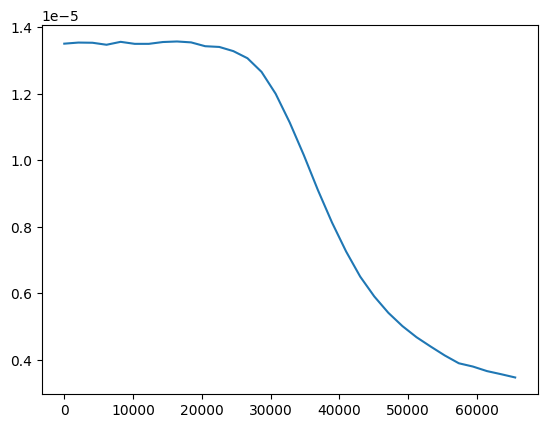

In [7]:
import numpy as np
import matplotlib.pyplot as plt

g, p = np.loadtxt('calib_checkerboard_period4.csv', delimiter=',').T
plt.plot(g, p)
plt.show()

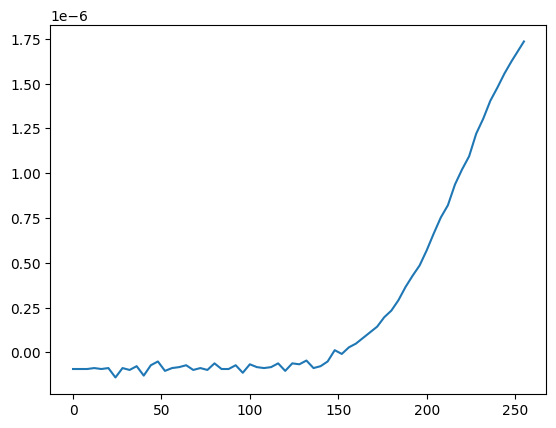

In [16]:
import numpy as np
import matplotlib.pyplot as plt

g, p = np.loadtxt('ramp_calib_v_p4.csv', delimiter=',').T
g = g // 256
plt.plot(g, p)
plt.show()

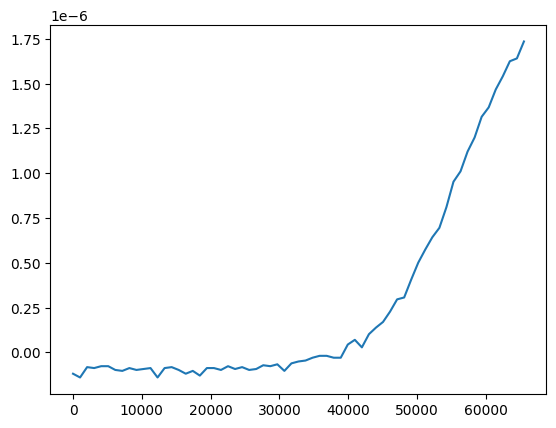

In [6]:
import numpy as np
import matplotlib.pyplot as plt

g, p = np.loadtxt('ramp_calib_v_p4.csv', delimiter=',').T
plt.plot(g, p)
plt.show()

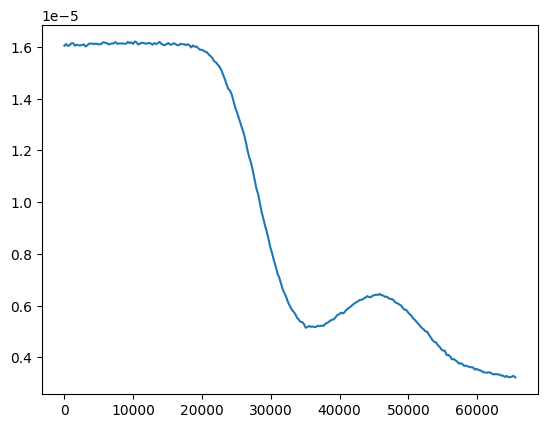

In [4]:
import numpy as np
import matplotlib.pyplot as plt

g, p = np.loadtxt('calib_checkerboard_period8.csv', delimiter=',').T
plt.plot(g, p)
plt.show()

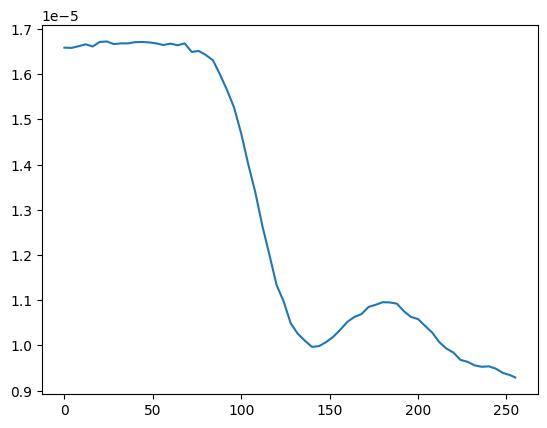

In [19]:
import numpy as np
import matplotlib.pyplot as plt

g, p = np.loadtxt('slmcali/20260527_123943_binary_calib_checkerboard_period16.csv', delimiter=',').T
g = g//256
plt.plot(g, p)
plt.show()

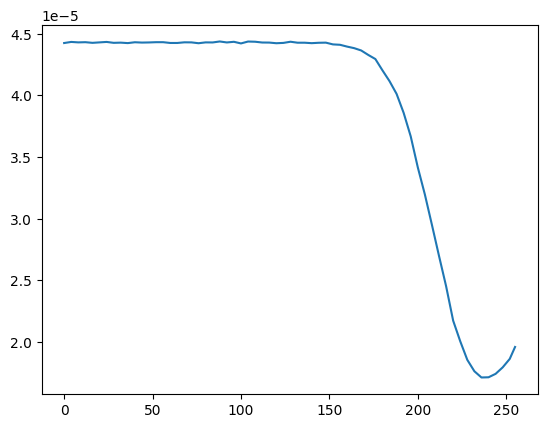

In [14]:
import numpy as np
import matplotlib.pyplot as plt

g, p = np.loadtxt('slmcali/20260527_152415_binary_calib_checkerboard_period16.csv', delimiter=',').T
g = g//256
plt.plot(g, p)
plt.show()

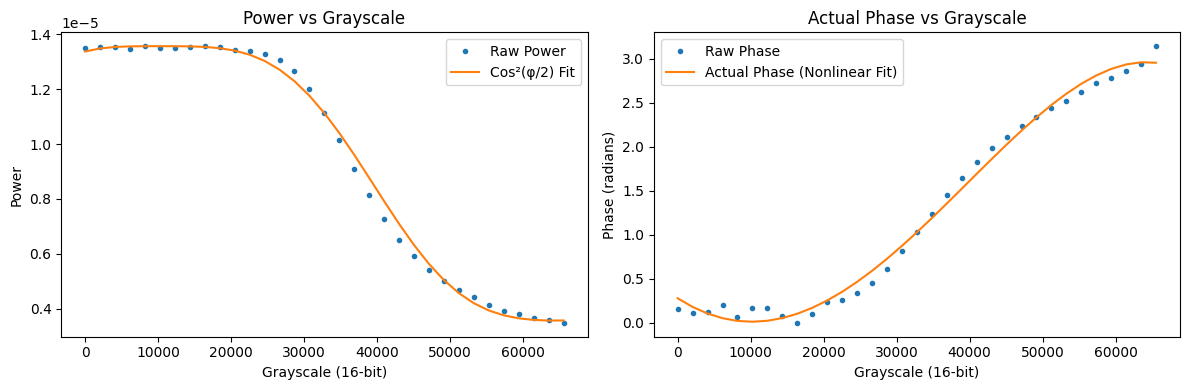

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. Load data (Assumes Col 0: 16-bit Grayscale, Col 1: Power)
g, p = np.loadtxt('calib_checkerboard_period4.csv', delimiter=',').T

# 2. Normalize power and calculate raw phase: P ∝ cos²(φ/2) -> φ = 2*arccos(√P_norm)
p_norm = np.clip((p - p.min()) / (p.max() - p.min()), 0, 1)
phi_raw = 2 * np.arccos(np.sqrt(p_norm))

# 3. Unwrap phase (min power is the turning point at π)
phi_raw[np.argmin(p):] = 2 * np.pi - phi_raw[np.argmin(p):]

# 4. Smooth the actual phase vs grayscale relationship (4th order polynomial)
phi_smooth = np.polyval(np.polyfit(g, phi_raw, 4), g)

# 5. Generate 16-bit LUT (Phase 0 -> 2π mapped to Grayscale 0 -> 65535)
desired_phases = np.linspace(0, 2 * np.pi, 65536)
lut = np.clip(interp1d(phi_smooth, g, fill_value="extrapolate")(desired_phases), 0, 65535).astype(np.uint16)
np.savetxt("slm_16bit_lut.csv", lut, fmt='%d', header='Grayscale_16bit', comments='')

# 6. Plotting Actual Phase vs 16-bit Grayscale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(g, p, '.', label='Raw Power')
ax1.plot(g, p.min() + (p.max() - p.min()) * np.cos(phi_smooth/2)**2, '-', label='Cos²(φ/2) Fit')
ax1.set(xlabel='Grayscale (16-bit)', ylabel='Power', title='Power vs Grayscale')
ax1.legend()

ax2.plot(g, phi_raw, '.', label='Raw Phase')
ax2.plot(g, phi_smooth, '-', label='Actual Phase (Nonlinear Fit)')
ax2.set(xlabel='Grayscale (16-bit)', ylabel='Phase (radians)', title='Actual Phase vs Grayscale')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# 1. Load data (assuming columns 0 and 1 are gray and power)
g, p = pd.read_csv('calib_checkerboard_period4.csv').values.T

# 2. Define model: P = A * cos^2(phi/2), where phi is a polynomial
def model(g, A, c1, c2, c3):
    return A * np.cos((c1*g + c2*g**2 + c3*g**3) / 2)**2

# 3. Fit the model (Initial guess: A = max power, linear phase slope)
popt, _ = curve_fit(model, g, p, p0=[p.max(), 0.01, 0, 0])

# 4. Extract the fitted phase
fitted_phase = popt[1]*g + popt[2]*g**2 + popt[3]*g**3

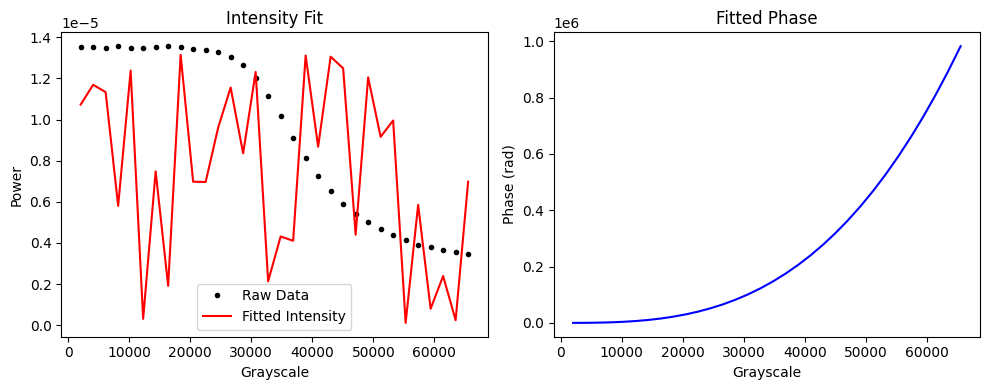

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Intensity plot
ax1.plot(g, p, 'k.', label='Raw Data')
ax1.plot(g, model(g, *popt), 'r-', label='Fitted Intensity')
ax1.set(xlabel='Grayscale', ylabel='Power', title='Intensity Fit')
ax1.legend()

# Phase plot
ax2.plot(g, fitted_phase, 'b-')
ax2.set(xlabel='Grayscale', ylabel='Phase (rad)', title='Fitted Phase')

plt.tight_layout()
plt.show()



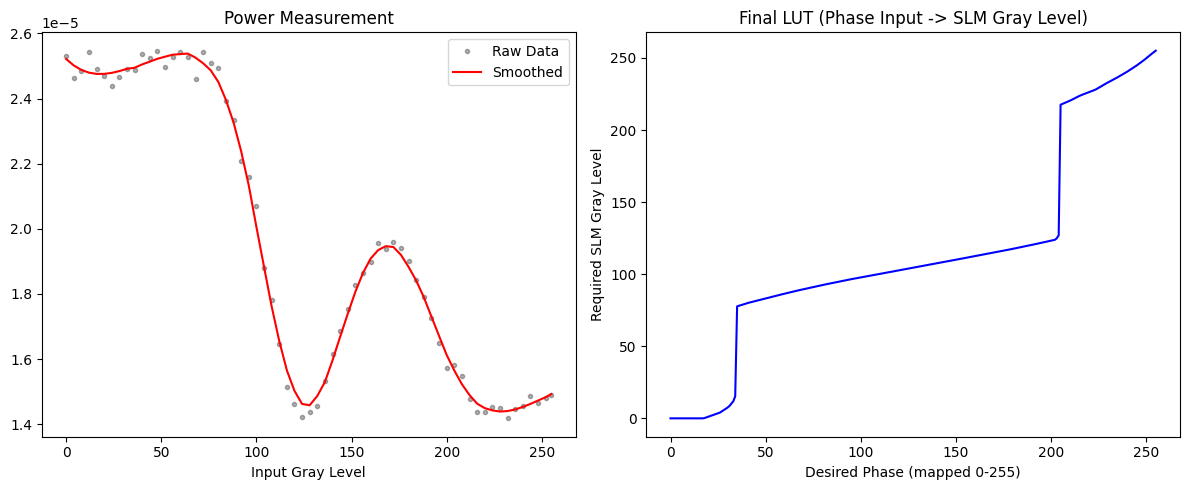

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

# 1. MOCK DATA LOADING
# Replace these with your actual measured values
# gray_levels = np.arange(256)
# power_measurements = np.array([...]) 

def generate_slm_lut(gray_levels, power_measurements):
    # 2. SMOOTHING
    # The raw data is noisy. We use a Savitzky-Golay filter to smooth it
    # without shifting the peaks/valleys.
    p_smooth = savgol_filter(power_measurements, window_length=15, polyorder=3)

    # 3. NORMALIZATION
    # Scale power between 0 and 1
    p_min = np.min(p_smooth)
    p_max = np.max(p_smooth)
    p_norm = (p_smooth - p_min) / (p_max - p_min)

    # 4. PHASE EXTRACTION (The "Unwrapping" Logic)
    # We assume: Power ~ cos(Phase). 
    # Phase = 0 at max power, Phase = pi at min power.
    
    # Find the index of the first minimum (around 135 in your graph)
    min_idx = np.argmin(p_norm)
    
    phase = np.zeros_like(p_norm)
    
    # Segment 1: 0 to pi (Falling edge)
    # Clamp values to [-1, 1] to avoid nan in arccos due to noise
    val1 = np.clip(2 * p_norm[:min_idx+1] - 1, -1, 1)
    phase[:min_idx+1] = np.arccos(val1)
    
    # Segment 2: pi to 2pi (Rising edge)
    # We subtract from 2*pi because arccos is symmetric
    val2 = np.clip(2 * p_norm[min_idx+1:] - 1, -1, 1)
    phase[min_idx+1:] = 2 * np.pi - np.arccos(val2)

    # 5. CREATE THE LINEAR LUT
    # We want a mapping where: Input (0-255) -> Phase (0 to 2pi)
    # Therefore, we need to find which Gray Level gives us a specific Phase.
    
    # Define the target phase range (usually 0 to 2*pi)
    # Note: If your SLM doesn't reach 2*pi, use np.max(phase)
    max_achievable_phase = np.max(phase)
    target_phases = np.linspace(0, max_achievable_phase, 256)

    # Invert the mapping: interp(x_new, x_old, y_old)
    # We want Gray Level as a function of Phase
    lut_gray_levels = np.interp(target_phases, phase, gray_levels)
    
    return lut_gray_levels, phase, p_smooth

# --- Example Usage ---
# (Generating dummy data that looks like your graph for demonstration)
g, p = np.loadtxt('slmcali/20260529_134623_binary_calib_column_period16.csv', delimiter=',').T
g = g // 256

lut, phase_curve, smoothed_p = generate_slm_lut(g, p)

# 6. VISUALIZATION
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(g, p, 'k.', alpha=0.3, label='Raw Data')
plt.plot(g, smoothed_p, 'r', label='Smoothed')
plt.title('Power Measurement')
plt.xlabel('Input Gray Level')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.linspace(0, 255, 256), lut, 'b')
plt.title('Final LUT (Phase Input -> SLM Gray Level)')
plt.xlabel('Desired Phase (mapped 0-255)')
plt.ylabel('Required SLM Gray Level')

plt.tight_layout()
plt.show()

# Save the LUT to a file
# np.savetxt("slm_lut.csv", lut.astype(int), fmt='%d')

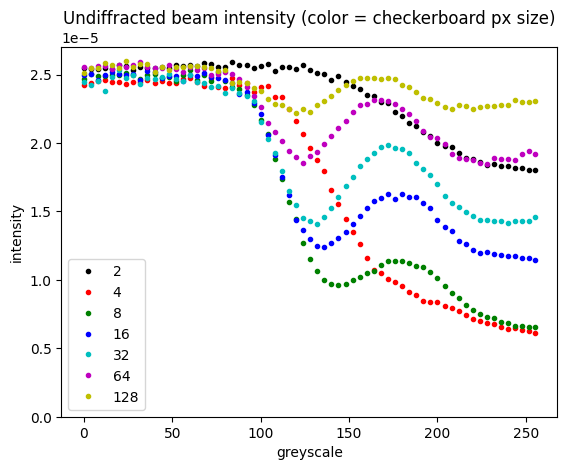

In [17]:
g, p = np.loadtxt('slmcali/20260529_135906_binary_calib_checkerboard_period2.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'k.', label='2')

g, p = np.loadtxt('slmcali/20260529_133559_binary_calib_checkerboard_period4.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'r.', label='4')

g, p = np.loadtxt('slmcali/20260529_134230_binary_calib_checkerboard_period8.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'g.', label='8')

g, p = np.loadtxt('slmcali/20260529_134305_binary_calib_checkerboard_period16.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'b.', label='16')

g, p = np.loadtxt('slmcali/20260529_134005_binary_calib_checkerboard_period32.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'c.', label='32')

g, p = np.loadtxt('slmcali/20260529_140453_binary_calib_checkerboard_period64.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'm.', label='64')

g, p = np.loadtxt('slmcali/20260529_140403_binary_calib_checkerboard_period128.csv', delimiter=',').T
g = g // 256
plt.plot(g, p, 'y.', label='128')

plt.legend()
plt.title('Undiffracted beam intensity (color = checkerboard px size)')
plt.ylabel('intensity')
plt.xlabel('greyscale')
plt.ylim(bottom=0)
plt.show()


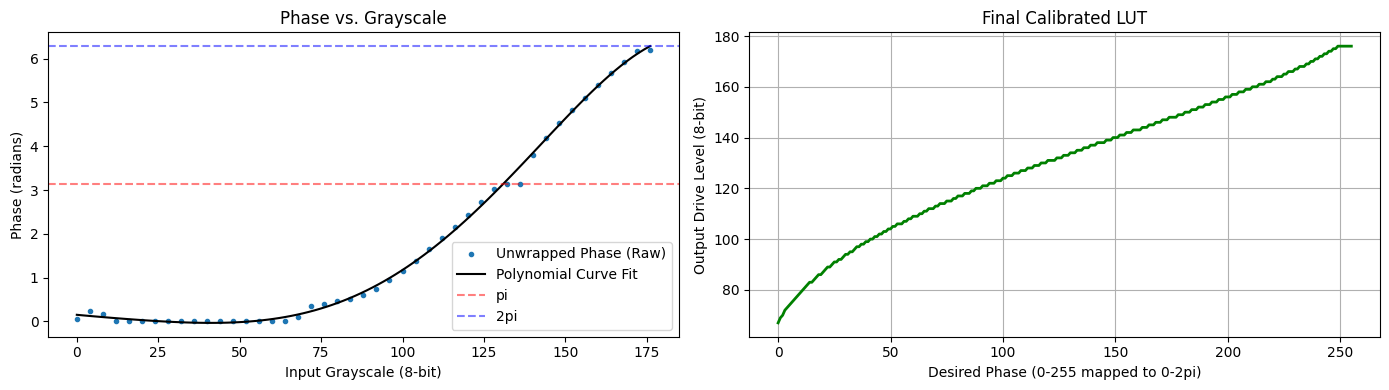

In [9]:
import numpy as np
from scipy.signal import find_peaks

def moving_average(x, window_size=5):
    return np.convolve(x, np.ones(window_size)/window_size, mode='valid')

def meadowlark_diffractive_calibration(g, p, output_bit_depth=12):
    """
    Calibrates SLM LUT using the 0th order diffractive method.
    """
    # 1. Apply Moving Average (pad to keep array length consistent)
    pad_width = 5 // 2
    p_padded = np.pad(p, (pad_width, 0), mode='edge')
    p_smooth = moving_average(p_padded, window_size=5)
    
    # 2. Find Extrema for 0th Order
    peaks, _ = find_peaks(p_smooth, distance=20, prominence=0.01 * np.max(p_smooth))
    valleys, _ = find_peaks(-p_smooth, distance=20, prominence=0.01 * np.max(p_smooth))
    
    # --- HARDCODED FIRST PEAK ---
    idx_0 = 0 
    
    # Find the first valley (pi phase shift) AFTER idx_0
    valid_valleys = [v for v in valleys if v > idx_0]
    if valid_valleys:
        idx_pi = valid_valleys[0]
    else:
        idx_pi = np.argmin(p_smooth)
            
    # Find the first peak (2pi phase shift) AFTER idx_pi
    valid_peaks_2pi = [p_idx for p_idx in peaks if p_idx > idx_pi]
    if valid_peaks_2pi:
        idx_2pi = valid_peaks_2pi[0]
    else:
        if idx_pi < len(p_smooth) - 1:
            idx_2pi = idx_pi + np.argmax(p_smooth[idx_pi:])
        else:
            idx_2pi = len(p_smooth) - 1
            
    # Safety check to strictly enforce ordering
    if idx_pi <= idx_0:
        idx_pi = idx_0 + 1
    if idx_2pi <= idx_pi:
        idx_2pi = idx_pi + 1
        
    idx_pi = min(idx_pi, len(g) - 2)
    idx_2pi = min(idx_2pi, len(g) - 1)

    # 3. Convert Intensity to Phase
    # Segment 1: 0 to pi
    g_seg1 = g[idx_0:idx_pi+1]
    p_seg1 = p_smooth[idx_0:idx_pi+1]
    
    # FIX: Force the first point to be the maximum to ensure phase starts exactly at 0
    p_max1 = p_seg1[0] 
    p_min1 = np.min(p_seg1)
    # Calculate normalized intensity and clip to [0, 1] to ignore noise bumps
    p_norm1 = (p_seg1 - p_min1) / (p_max1 - p_min1 + 1e-8)
    p_norm1 = np.clip(p_norm1, 0, 1)
    phase_seg1 = 2 * np.arccos(np.sqrt(p_norm1))
    
    # Segment 2: pi to 2pi
    g_seg2 = g[idx_pi+1:idx_2pi+1]
    p_seg2 = p_smooth[idx_pi+1:idx_2pi+1]
    
    # FIX: Force the first point of seg2 to be the minimum (valley)
    p_min2 = p_seg2[0]
    p_max2 = np.max(p_seg2)
    p_norm2 = (p_seg2 - p_min2) / (p_max2 - p_min2 + 1e-8)
    p_norm2 = np.clip(p_norm2, 0, 1)
    phase_seg2 = 2 * np.pi - 2 * np.arccos(np.sqrt(p_norm2))
    
    g_combined = np.concatenate([g_seg1, g_seg2])
    phase_combined = np.concatenate([phase_seg1, phase_seg2])
    
    # 4. Polynomial Fit
    poly_coeffs = np.polyfit(g_combined, phase_combined, 5)
    poly_fit_func = np.poly1d(poly_coeffs)
    
    # 5. Generate LUT
    target_phases = np.linspace(0, 2 * np.pi, 256)
    g_dense = np.linspace(g_combined[0], g_combined[-1], 1000)
    
    phase_dense = poly_fit_func(g_dense)
    
    # Ensure the fitted curve starts exactly at 0 and is strictly increasing
    phase_dense = phase_dense - phase_dense[0] 
    phase_dense = np.maximum.accumulate(phase_dense)
    
    # Interpolate to find the grayscale values for the target phases
    lut_input_g = np.interp(target_phases, phase_dense, g_dense)
    
    # Scale to output bit depth
    max_out_val = (2 ** output_bit_depth) - 1
    lut_final = (lut_input_g / 255.0) * max_out_val
    
    return np.round(lut_final).astype(int), g_combined, phase_combined, poly_fit_func

# --- Example Usage ---
# Load your data
# g, p = np.loadtxt('slmcali/20260529_134305_binary_calib_checkerboard_period16.csv', delimiter=',').T
g, p = np.loadtxt('slmcali/20260529_134005_binary_calib_checkerboard_period32.csv', delimiter=',').T
# g, p = np.loadtxt('slmcali/20260529_140453_binary_calib_checkerboard_period64.csv', delimiter=',').T


g = g // 256 # Scale back to 0-255

# Generate LUT (using 8-bit output as requested in your traceback)
lut_8bit, g_raw, phase_raw, fit_func = meadowlark_diffractive_calibration(g, p, output_bit_depth=8)

# --- Visualization ---
plt.figure(figsize=(14, 4))

# Plot 1: Unwrapped Phase and Curve Fit
plt.subplot(1, 2, 1)
plt.plot(g_raw, phase_raw, '.', label='Unwrapped Phase (Raw)')
g_plot = np.linspace(g_raw[0], g_raw[-1], 100)
plt.plot(g_plot, fit_func(g_plot), 'k-', label='Polynomial Curve Fit')
plt.axhline(np.pi, color='r', linestyle='--', alpha=0.5, label=r'pi')
plt.axhline(2*np.pi, color='b', linestyle='--', alpha=0.5, label=r'2pi')
plt.title('Phase vs. Grayscale')
plt.xlabel('Input Grayscale (8-bit)')
plt.ylabel('Phase (radians)')
plt.legend()

# Plot 2: Final LUT
plt.subplot(1, 2, 2)
plt.plot(np.arange(256), lut_8bit, 'g-', lw=2)
plt.title('Final Calibrated LUT')
plt.xlabel('Desired Phase (0-255 mapped to 0-2pi)')
plt.ylabel('Output Drive Level (8-bit)')
plt.grid(True)

plt.tight_layout()
plt.show()

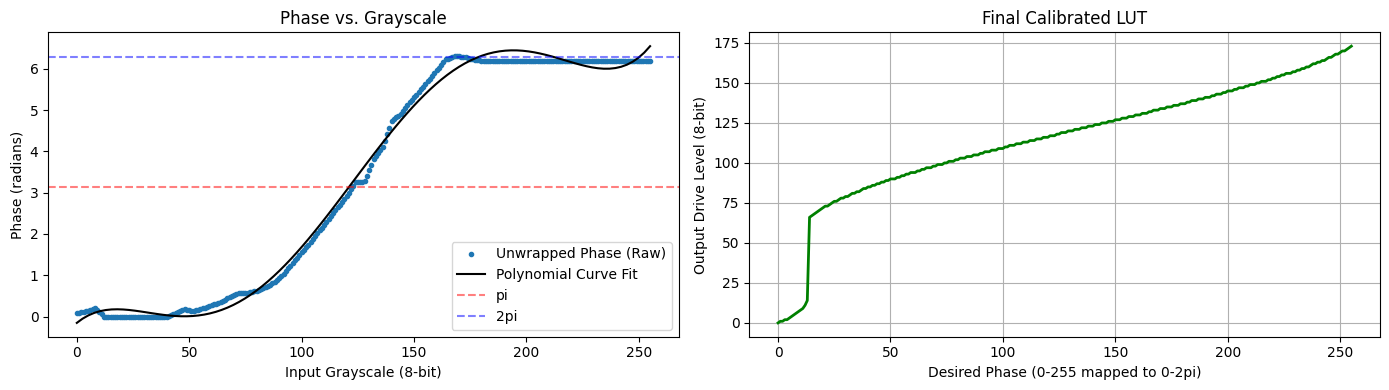

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ... (Keep your moving_average and meadowlark_diffractive_calibration functions here) ...
# Modify meadowlark_diffractive_calibration to just return the raw phase and g_combined
# without doing the final polynomial fit inside the function, or just extract them from the output.
def moving_average(x, window_size=5):
    return np.convolve(x, np.ones(window_size)/window_size, mode='valid')

def meadowlark_diffractive_calibration(g, p, output_bit_depth=12):
    """
    Calibrates SLM LUT using the 0th order diffractive method.
    """
    # 1. Apply Moving Average (pad to keep array length consistent)
    pad_width = 5 // 2
    p_padded = np.pad(p, (pad_width, pad_width), mode='edge')
    p_smooth = moving_average(p_padded, window_size=5)
    
    # 2. Find Extrema for 0th Order
    peaks, _ = find_peaks(p_smooth, distance=20, prominence=0.01 * np.max(p_smooth))
    valleys, _ = find_peaks(-p_smooth, distance=20, prominence=0.01 * np.max(p_smooth))
    
    # --- HARDCODED FIRST PEAK ---
    idx_0 = 0 
    
    # Find the first valley (pi phase shift) AFTER idx_0
    valid_valleys = [v for v in valleys if v > idx_0]
    if valid_valleys:
        idx_pi = valid_valleys[0]
    else:
        idx_pi = np.argmin(p_smooth)
            
    # Find the first peak (2pi phase shift) AFTER idx_pi
    valid_peaks_2pi = [p_idx for p_idx in peaks if p_idx > idx_pi]
    if valid_peaks_2pi:
        idx_2pi = valid_peaks_2pi[0]
    else:
        if idx_pi < len(p_smooth) - 1:
            idx_2pi = idx_pi + np.argmax(p_smooth[idx_pi:])
        else:
            idx_2pi = len(p_smooth) - 1
            
    # Safety check to strictly enforce ordering
    if idx_pi <= idx_0:
        idx_pi = idx_0 + 1
    if idx_2pi <= idx_pi:
        idx_2pi = idx_pi + 1
        
    idx_pi = min(idx_pi, len(g) - 2)
    idx_2pi = min(idx_2pi, len(g) - 1)

    # 3. Convert Intensity to Phase
    # Segment 1: 0 to pi
    g_seg1 = g[idx_0:idx_pi+1]
    p_seg1 = p_smooth[idx_0:idx_pi+1]
    
    # FIX: Force the first point to be the maximum to ensure phase starts exactly at 0
    p_max1 = p_seg1[0] 
    p_min1 = np.min(p_seg1)
    # Calculate normalized intensity and clip to [0, 1] to ignore noise bumps
    p_norm1 = (p_seg1 - p_min1) / (p_max1 - p_min1 + 1e-8)
    p_norm1 = np.clip(p_norm1, 0, 1)
    phase_seg1 = 2 * np.arccos(np.sqrt(p_norm1))
    
    # Segment 2: pi to 2pi
    g_seg2 = g[idx_pi+1:idx_2pi+1]
    p_seg2 = p_smooth[idx_pi+1:idx_2pi+1]
    
    # FIX: Force the first point of seg2 to be the minimum (valley)
    p_min2 = p_seg2[0]
    p_max2 = np.max(p_seg2)
    p_norm2 = (p_seg2 - p_min2) / (p_max2 - p_min2 + 1e-8)
    p_norm2 = np.clip(p_norm2, 0, 1)
    phase_seg2 = 2 * np.pi - 2 * np.arccos(np.sqrt(p_norm2))
    
    g_combined = np.concatenate([g_seg1, g_seg2])
    phase_combined = np.concatenate([phase_seg1, phase_seg2])
    
    # 4. Polynomial Fit
    poly_coeffs = np.polyfit(g_combined, phase_combined, 5)
    poly_fit_func = np.poly1d(poly_coeffs)
    
    # 5. Generate LUT
    target_phases = np.linspace(0, 2 * np.pi, 256)
    g_dense = np.linspace(g_combined[0], g_combined[-1], 1000)
    
    phase_dense = poly_fit_func(g_dense)
    
    # Ensure the fitted curve starts exactly at 0 and is strictly increasing
    phase_dense = phase_dense - phase_dense[0] 
    phase_dense = np.maximum.accumulate(phase_dense)
    
    # Interpolate to find the grayscale values for the target phases
    lut_input_g = np.interp(target_phases, phase_dense, g_dense)
    
    # Scale to output bit depth
    max_out_val = (2 ** output_bit_depth) - 1
    lut_final = (lut_input_g / 255.0) * max_out_val
    
    return np.round(lut_final).astype(int), g_combined, phase_combined, poly_fit_func

def process_and_extrapolate(files, periods):
    phases_interp = []
    common_g = np.arange(0, 256) # Common grayscale axis for interpolation
    
    for file in files:
        g, p = np.loadtxt(file, delimiter=',').T
        g = g // 256 # Scale to 8-bit
        
        # Get the raw phase for this specific period
        _, g_raw, phase_raw, _ = meadowlark_diffractive_calibration(g, p, output_bit_depth=8)
        
        # Interpolate this period's phase onto the common grayscale axis
        # (Using np.interp ensures all curves are aligned on the X-axis)
        phase_aligned = np.interp(common_g, g_raw, phase_raw)
        phases_interp.append(phase_aligned)
        
    phases_interp = np.array(phases_interp) # Shape: (num_periods, 256)
    
    # Extrapolate to infinite period (1 / period -> 0)
    inv_periods = 1.0 / np.array(periods)
    extrapolated_phase = np.zeros_like(common_g, dtype=float)
    
    # For each grayscale level, fit a line: Phase = m * (1/Period) + c
    # The intercept 'c' is the phase at 1/Period = 0 (infinite period)
    for i in range(len(common_g)):
        # polyfit degree 1 (linear extrapolation)
        coeffs = np.polyfit(inv_periods, phases_interp[:, i], 1)
        extrapolated_phase[i] = coeffs[1] # The intercept
        
    # Now, fit your final 5th order polynomial to the EXTRAPOLATED phase
    poly_coeffs = np.polyfit(common_g, extrapolated_phase, 5)
    poly_fit_func = np.poly1d(poly_coeffs)
    
    # Generate Final LUT from the extrapolated fit
    target_phases = np.linspace(0, 2 * np.pi, 256)
    g_dense = np.linspace(common_g[0], common_g[-1], 1000)
    phase_dense = poly_fit_func(g_dense)
    
    phase_dense = phase_dense - phase_dense[0] 
    phase_dense = np.maximum.accumulate(phase_dense)
    
    lut_input_g = np.interp(target_phases, phase_dense, g_dense)
    lut_final = (lut_input_g / 255.0) * 255.0
    
    return np.round(lut_final).astype(int), common_g, extrapolated_phase, poly_fit_func

# Example Usage:
files = [
    # 'slmcali/20260529_134230_binary_calib_checkerboard_period8.csv',
    'slmcali/20260529_134305_binary_calib_checkerboard_period16.csv',
    'slmcali/20260529_134005_binary_calib_checkerboard_period32.csv',
    'slmcali/20260529_140453_binary_calib_checkerboard_period64.csv'
]
periods = [16, 32, 64]

lut_8bit, g_extrap, phase_extrap, fit_func = process_and_extrapolate(files, periods)

# --- Visualization ---
plt.figure(figsize=(14, 4))

# Plot 1: Unwrapped Phase and Curve Fit
plt.subplot(1, 2, 1)
plt.plot(g_extrap, phase_extrap, '.', label='Unwrapped Phase (Raw)')
g_plot = np.linspace(g_extrap[0], g_extrap[-1], 100)
plt.plot(g_plot, fit_func(g_plot), 'k-', label='Polynomial Curve Fit')
plt.axhline(np.pi, color='r', linestyle='--', alpha=0.5, label=r'pi')
plt.axhline(2*np.pi, color='b', linestyle='--', alpha=0.5, label=r'2pi')
plt.title('Phase vs. Grayscale')
plt.xlabel('Input Grayscale (8-bit)')
plt.ylabel('Phase (radians)')
plt.legend()

# Plot 2: Final LUT
plt.subplot(1, 2, 2)
plt.plot(np.arange(256), lut_8bit, 'g-', lw=2)
plt.title('Final Calibrated LUT')
plt.xlabel('Desired Phase (0-255 mapped to 0-2pi)')
plt.ylabel('Output Drive Level (8-bit)')
plt.grid(True)

plt.tight_layout()
plt.show()